In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import os
import re

import sklearn
import sklearn.model_selection
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import tensorflow as tf

# Use keras 2
import tf_keras as tfk
os.environ["TF_USE_LEGACY_KERAS"] ="1"

## Use keras 3
#tfk = tf.keras

from normalizing_flow import MAF

2025-11-03 16:14:19.420750: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-03 16:14:19.420818: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-03 16:14:19.420851: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-03 16:14:19.430338: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [3]:
flist = np.loadtxt('data/QCD_NF8/flist', dtype=str)
flist_tokens = []
for f in flist:
    f=f.replace('_bis', '')
    f=f.replace('_ter', '')
    f=f.replace('Nt8_', '8 ')
    f=f.replace('NF8_', '')
    f=f.replace('ferm_Ns', '')
    f=f.replace('b', '')
    f=f.replace('M0p', '0.')
    f=f.replace('_', ' ')
    tokens = f.split()
    tokens = [tokens[3], tokens[2], tokens[0], tokens[1]]
    flist_tokens = flist_tokens + [tokens]

In [4]:
def extract_vars(l):
    beta = float(l[0])
    m = float(l[1])
    ns = float(l[2])
    nt = float(l[3])
    return beta, m, ns, nt

In [5]:
flist[0]

'ferm_Ns12_Nt8_NF8_M0p0085_b2.2550'

In [6]:
flist_tokens[0]

['2.2550', '0.0085', '12', '8']

In [7]:
extract_vars(flist_tokens[0])

(2.255, 0.0085, 12.0, 8.0)

In [8]:
therm = 400
each = 1

plaq = np.loadtxt('data/QCD_NF8/'+flist[0])[therm::each,2]
ff = np.loadtxt('data/QCD_NF8/'+flist[0])[therm::each,4]
(beta, m, ns, nt) = extract_vars(flist_tokens[0])
M = plaq
M = np.vstack([M, ff])
M = np.vstack([M, beta*np.ones(plaq.size)])
M = np.vstack([M, m*np.ones(plaq.size)])
M = np.vstack([M, ns*np.ones(plaq.size)])

for i in np.arange(1,flist.size):
    plaq = np.loadtxt('data/QCD_NF8/'+flist[i])[therm::each,2]
    ff = np.loadtxt('data/QCD_NF8/'+flist[i])[therm::each,4]
    (beta, m, ns, nt) = extract_vars(flist_tokens[i])
    N = plaq
    N = np.vstack([N, ff])
    N = np.vstack([N, beta*np.ones(plaq.size)])
    N = np.vstack([N, m*np.ones(plaq.size)])
    N = np.vstack([N, ns*np.ones(plaq.size)])
    M = np.hstack([M, N])
M = M.transpose()

In [9]:
M.shape

(2507411, 5)

In [10]:
M[0:3]

array([[3.00146807e-01, 1.00105486e+00, 2.25500000e+00, 8.50000000e-03,
        1.20000000e+01],
       [3.00146807e-01, 1.16423067e+00, 2.25500000e+00, 8.50000000e-03,
        1.20000000e+01],
       [3.00146807e-01, 1.05576065e+00, 2.25500000e+00, 8.50000000e-03,
        1.20000000e+01]])

In [11]:
np.argwhere(np.isnan(M))

array([], shape=(0, 2), dtype=int64)

In [12]:
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(M, np.ones(M.shape[0]))

In [13]:
scaler=MinMaxScaler()
scaler.fit_transform(x_train)
x_train=scaler.transform(x_train)
x_test=scaler.transform(x_test)

In [14]:
nvars = 2 # plaq, ff
ncondvars = 3 # beta, m, ns (NO nt)

nflow = MAF(nvars, ncondvars, nblocks=12, hidden_units=[64, 64], activation='relu', last_activation='relu', l1=0.0, l2=1.0e-4)

#print(nflow.trainable_variables)

nflow.compile(optimizer=tfk.optimizers.Adam(learning_rate=1.0e-3), loss=lambda _, log_prob: -log_prob)

2025-11-03 16:14:47.910431: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 37644 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:25:00.0, compute capability: 8.0


In [15]:
batch_size = 32768
#batch_size = 65536
history = nflow.fit(x=[x_train[:,:nvars], x_train[:,nvars:nvars+ncondvars]],
          y=np.zeros((x_train.shape[0], 0), dtype=np.float32),
          batch_size=batch_size,
          epochs=500,
          steps_per_epoch=x_train.shape[0] // batch_size,
          shuffle=True,
          verbose=True,
          validation_data=([x_test[:,:nvars], x_test[:,nvars:nvars+ncondvars]],np.zeros((x_test.shape[0], 0), dtype=np.float32)),
          callbacks=[tfk.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=30, restore_best_weights=True)])


Epoch 1/500


2025-11-03 16:15:11.500982: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fe269b7c380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-03 16:15:11.501029: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2025-11-03 16:15:11.506607: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-03 16:15:11.523735: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2025-11-03 16:15:11.607922: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


57/57 [==============================] - 32s 74ms/step - loss: 0.0362 - val_loss: -1.1100
Epoch 2/500
57/57 [==============================] - 2s 35ms/step - loss: -2.3292 - val_loss: -3.2087
Epoch 3/500
57/57 [==============================] - 2s 38ms/step - loss: -3.4051 - val_loss: -3.5316
Epoch 4/500
57/57 [==============================] - 2s 36ms/step - loss: -3.5373 - val_loss: -3.5789
Epoch 5/500
57/57 [==============================] - 2s 37ms/step - loss: -3.6235 - val_loss: -3.6787
Epoch 6/500
57/57 [==============================] - 2s 37ms/step - loss: -3.6936 - val_loss: -3.7088
Epoch 7/500
57/57 [==============================] - 2s 39ms/step - loss: -3.7420 - val_loss: -3.8004
Epoch 8/500
57/57 [==============================] - 2s 38ms/step - loss: -3.8080 - val_loss: -3.8135
Epoch 9/500
57/57 [==============================] - 2s 37ms/step - loss: -3.9340 - val_loss: -3.9819
Epoch 10/500
57/57 [==============================] - 2s 38ms/step - loss: -3.9552 - val_loss:

57/57 [==============================] - 2s 38ms/step - loss: -4.6139 - val_loss: -4.6045
Epoch 160/500
57/57 [==============================] - 2s 39ms/step - loss: -4.6240 - val_loss: -4.6315
Epoch 161/500
57/57 [==============================] - 2s 40ms/step - loss: -4.6161 - val_loss: -4.6420
Epoch 162/500
57/57 [==============================] - 2s 38ms/step - loss: -4.6266 - val_loss: -4.6203
Epoch 163/500
57/57 [==============================] - 2s 38ms/step - loss: -4.6123 - val_loss: -4.6118
Epoch 164/500
57/57 [==============================] - 2s 37ms/step - loss: -4.6255 - val_loss: -4.6116
Epoch 165/500
57/57 [==============================] - 2s 39ms/step - loss: -4.6272 - val_loss: -4.6386
Epoch 166/500
57/57 [==============================] - 2s 40ms/step - loss: -4.6180 - val_loss: -4.6460
Epoch 167/500
57/57 [==============================] - 2s 38ms/step - loss: -4.6167 - val_loss: -4.6324
Epoch 168/500
57/57 [==============================] - 2s 37ms/step - loss: -4

Epoch 238/500
57/57 [==============================] - 2s 37ms/step - loss: -4.6733 - val_loss: -4.6842
Epoch 239/500
57/57 [==============================] - 2s 37ms/step - loss: -4.6685 - val_loss: -4.6855
Epoch 240/500
57/57 [==============================] - 2s 38ms/step - loss: -4.6682 - val_loss: -4.6866
Epoch 241/500
57/57 [==============================] - 2s 36ms/step - loss: -4.6657 - val_loss: -4.6767
Epoch 242/500
57/57 [==============================] - 2s 35ms/step - loss: -4.6683 - val_loss: -4.6789
Epoch 243/500
57/57 [==============================] - 2s 36ms/step - loss: -4.6776 - val_loss: -4.6902
Epoch 244/500
57/57 [==============================] - 2s 35ms/step - loss: -4.6643 - val_loss: -4.6832
Epoch 245/500
57/57 [==============================] - 2s 36ms/step - loss: -4.6723 - val_loss: -4.6893
Epoch 246/500
57/57 [==============================] - 2s 36ms/step - loss: -4.6738 - val_loss: -4.6838
Epoch 247/500
57/57 [==============================] - 2s 36ms/s

Epoch 317/500
57/57 [==============================] - 2s 36ms/step - loss: -4.6871 - val_loss: -4.6739
Epoch 318/500
57/57 [==============================] - 2s 36ms/step - loss: -4.6952 - val_loss: -4.7078
Epoch 319/500
57/57 [==============================] - 2s 37ms/step - loss: -4.6863 - val_loss: -4.6744
Epoch 320/500
57/57 [==============================] - 2s 36ms/step - loss: -4.6953 - val_loss: -4.7089
Epoch 321/500
57/57 [==============================] - 2s 35ms/step - loss: -4.6974 - val_loss: -4.7064
Epoch 322/500
57/57 [==============================] - 2s 35ms/step - loss: -4.6863 - val_loss: -4.7030
Epoch 323/500
57/57 [==============================] - 2s 36ms/step - loss: -4.6843 - val_loss: -4.6774
Epoch 324/500
57/57 [==============================] - 2s 35ms/step - loss: -4.6948 - val_loss: -4.6971
Epoch 325/500
57/57 [==============================] - 2s 35ms/step - loss: -4.7040 - val_loss: -4.7059
Epoch 326/500
57/57 [==============================] - 2s 36ms/s

Epoch 396/500
57/57 [==============================] - 2s 39ms/step - loss: -4.7011 - val_loss: -4.6946
Epoch 397/500
57/57 [==============================] - 2s 38ms/step - loss: -4.7164 - val_loss: -4.6974
Epoch 398/500
57/57 [==============================] - 2s 38ms/step - loss: -4.7089 - val_loss: -4.7208
Epoch 399/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7014 - val_loss: -4.7234
Epoch 400/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7226 - val_loss: -4.6007
Epoch 401/500
57/57 [==============================] - 2s 35ms/step - loss: -4.7037 - val_loss: -4.7198
Epoch 402/500
57/57 [==============================] - 2s 38ms/step - loss: -4.7180 - val_loss: -4.7190
Epoch 403/500
57/57 [==============================] - 2s 39ms/step - loss: -4.7106 - val_loss: -4.6782
Epoch 404/500
57/57 [==============================] - 2s 38ms/step - loss: -4.7160 - val_loss: -4.7200
Epoch 405/500
57/57 [==============================] - 2s 38ms/s

Epoch 475/500
57/57 [==============================] - 2s 39ms/step - loss: -4.7362 - val_loss: -4.7352
Epoch 476/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7333 - val_loss: -4.7407
Epoch 477/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7278 - val_loss: -4.7159
Epoch 478/500
57/57 [==============================] - 2s 39ms/step - loss: -4.7273 - val_loss: -4.6936
Epoch 479/500
57/57 [==============================] - 2s 38ms/step - loss: -4.7304 - val_loss: -4.7331
Epoch 480/500
57/57 [==============================] - 2s 37ms/step - loss: -4.7256 - val_loss: -4.7111
Epoch 481/500
57/57 [==============================] - 2s 39ms/step - loss: -4.7361 - val_loss: -4.7391
Epoch 482/500
57/57 [==============================] - 2s 35ms/step - loss: -4.7235 - val_loss: -4.7114
Epoch 483/500
57/57 [==============================] - 2s 36ms/step - loss: -4.7217 - val_loss: -4.7344
Epoch 484/500
57/57 [==============================] - 2s 38ms/s

(-8.0, 2.0)

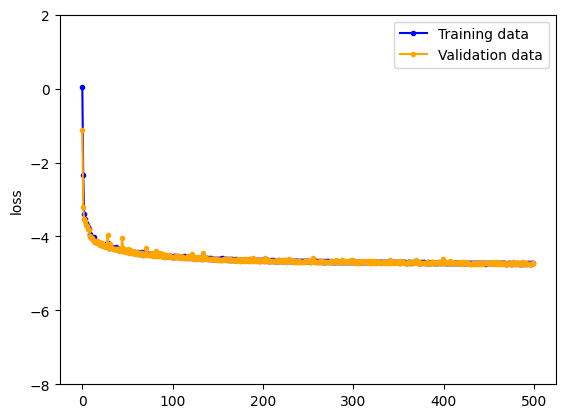

In [16]:
plt.plot(history.history['loss'], ls='-', marker='.', color='blue', label='Training data')
plt.plot(history.history['val_loss'], ls='-', marker='.', color='orange', label='Validation data')
plt.legend()
plt.ylabel('loss')
plt.ylim(-8,2)

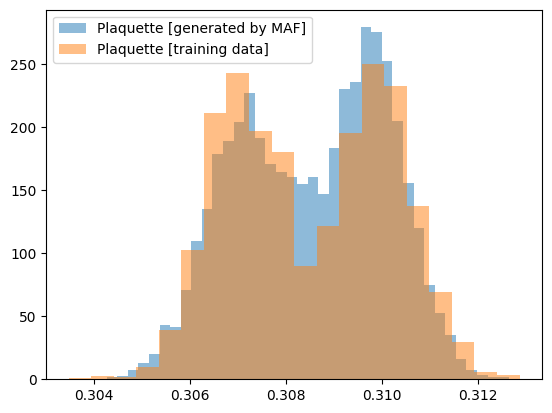

In [17]:
nsamples = 10000

cond = scaler.transform(np.array([[0.0, 0.0, 2.2950, 0.01, 16]]))[0][2:]
samples = nflow.sample(cond, nsamples)
h = np.vstack([samples[:,0], samples[:,1]])
h = np.vstack([h, np.zeros((3,nsamples))])
h = h.transpose()
unscaled_samples = scaler.inverse_transform(h)[:,0]
plt.hist(unscaled_samples, 40, alpha=0.5, density=True, label='Plaquette [generated by MAF]');

unscaled_x_train = scaler.inverse_transform(x_train)
plt.hist(unscaled_x_train[(unscaled_x_train[:,2] == 2.2950) & (unscaled_x_train[:,3] == 0.01)  & (unscaled_x_train[:,4] == 16)][:,0], 20, alpha=0.5, density=True, label='Plaquette [training data]');

plt.legend()

In [18]:
nflow.save_weights('my_qcdnf8_model.weights')